<a href="https://colab.research.google.com/github/SadevSaranga/OnlineQuiz/blob/main/DeepLearning01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch #Pytorch Deep Learning
import torch.nn as nn
import torch.optim  as optim

#inputs
x = torch.tensor([[1.0], [2.0],[3.0],[4.0], [5.0]])
y = torch.tensor([[5.0],[10.0],[15.0],[20.0],[25.0]])

#Neural Network
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(1,16) #16 Neurons
        self.fc2= nn.Linear(16,1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleNN()

loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001) #Measuring the loss

for epoch in range(1000):
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

test_input = torch.tensor([[6.0]])
predicted_output = model(test_input)
print(f'Predicted output for input {test_input.item()}: {predicted_output.item()}')

Epoch 0, Loss: 232.132080078125
Epoch 100, Loss: 0.31867533922195435
Epoch 200, Loss: 0.1833382546901703
Epoch 300, Loss: 0.1049509197473526
Epoch 400, Loss: 0.0597832091152668
Epoch 500, Loss: 0.03390609472990036
Epoch 600, Loss: 0.019159499555826187
Epoch 700, Loss: 0.010795073583722115
Epoch 800, Loss: 0.006068500690162182
Epoch 900, Loss: 0.0034059002064168453
Predicted output for input 6.0: 29.93033790588379


In [ ]:
import tensorflow as tf

#inputs
x = torch.tensor([[1.0], [2.0],[3.0],[4.0], [5.0]])
y = torch.tensor([[5.0],[10.0],[15.0],[20.0],[25.0]])


#Model
model = tf.keras.Sequential([
     tf.keras.layers.Dense(16, activation='relu', input_shape=[1]),
    tf.keras.layers.Dense(1)
])

#Compile model
model.compile(
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.001),
    loss = 'mean_squared_error'
)

model.fit(x,y,epochs=1000, verbose = 0)

test_input = torch.tensor([[6.0]])
predicted_output = model(test_input)
print("Prediction for 6:" + str(predicted_output))

Prediction for 6:tf.Tensor([[29.900492]], shape=(1, 1), dtype=float32)


In [ ]:
#Pytorch - MNIST
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load the MNIST dataset
transfrom = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transfrom)
test_data = datasets.MNIST(root='./data', train=False, transform=transfrom)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

#Model
class MNIST_NN(nn.Module):
    def __init__(self):
        super(MNIST_NN, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MNIST_NN()

#Loss & optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

#Training loop
for epoch in range(20):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

#Accuracy
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Epoch 1, Loss: 2.2907166481018066
Epoch 2, Loss: 2.2301454544067383
Epoch 3, Loss: 2.126049518585205
Epoch 4, Loss: 1.976281762123108
Epoch 5, Loss: 1.8605519533157349
Epoch 6, Loss: 1.5155932903289795
Epoch 7, Loss: 1.0735090970993042
Epoch 8, Loss: 1.0330719947814941
Epoch 9, Loss: 0.7310652136802673
Epoch 10, Loss: 0.8347880840301514
Epoch 11, Loss: 0.7370485067367554
Epoch 12, Loss: 0.8540260195732117
Epoch 13, Loss: 0.8332269191741943
Epoch 14, Loss: 0.38225528597831726
Epoch 15, Loss: 0.4611002206802368
Epoch 16, Loss: 0.5822296142578125
Epoch 17, Loss: 0.514092206954956
Epoch 18, Loss: 0.4936322867870331
Epoch 19, Loss: 0.5702059268951416
Epoch 20, Loss: 0.2929663360118866
Test Accuracy: 88.39%


In [ ]:
#MNIST- TNESORLOW
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0 #Normlize
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

#Model
model =Sequential  ([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

#Compile model

model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

#Train
model.fit(x_train, y_train, epochs=10, batch_size=64, verbose=1)

#Evaluate
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8612 - loss: 0.4959
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9632 - loss: 0.1228
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9754 - loss: 0.0811
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9832 - loss: 0.0560
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9865 - loss: 0.0450
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9901 - loss: 0.0327
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9911 - loss: 0.0276
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9933 - loss: 0.0216
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9947 - loss: 0.0174
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9947 - loss: 0.0164
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9732 - loss: 0.0986
Test Loss: 0.0872, Test Accuracy: 97.64%


Epoch 1, Loss: 2.283510208129883
Epoch 2, Loss: 2.231721878051758
Epoch 3, Loss: 2.179658889770508
Epoch 4, Loss: 2.115847110748291
Epoch 5, Loss: 2.028139352798462
Test Accuracy: 66.27%


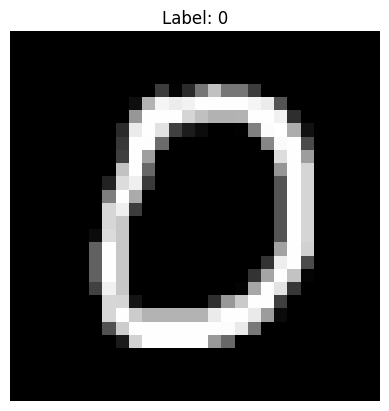

Predicted Label: 0


In [ ]:
#Pytorch - MNIST
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load the MNIST dataset
transfrom = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transfrom)
test_data = datasets.MNIST(root='./data', train=False, transform=transfrom)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

#Model
class MNIST_NN(nn.Module):
    def __init__(self):
        super(MNIST_NN, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MNIST_NN()

#Loss & optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

#Training loop
for epoch in range(5):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

#Accuracy
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

#Image Recognition
import matplotlib.pyplot as plt

#image
image,label = test_data[10]

#show image
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

#Predict
with torch.no_grad():
    output = model(image.unsqueeze(0))
    predicted_label = torch.argmax(output, dim=1).item()
    print(f"Predicted Label: {predicted_label}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8601 - loss: 0.4857
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9625 - loss: 0.1244
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9766 - loss: 0.0769
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9829 - loss: 0.0554
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9862 - loss: 0.0436
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9895 - loss: 0.0336
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9920 - loss: 0.0264
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9922 - loss: 0.0234
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9940 - loss: 0.0178
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9947 - loss: 0.0162
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9733 - loss: 0.1093
Test Loss: 0.0885, Test Accuracy: 97.72%


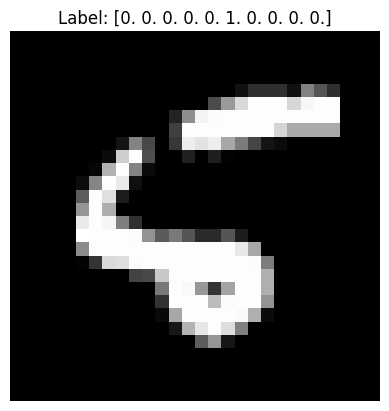

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted Label: 5


In [ ]:
#MNIST- TNESORLOW
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0 #Normlize
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

#Model
model =Sequential  ([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

#Compile model

model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

#Train
model.fit(x_train, y_train, epochs=10, batch_size=64, verbose=1)

#Evaluate
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy*100:.2f}%")

#image recoginiton
import matplotlib.pyplot as plt

#pick and image
plt.imshow(x_test[8],cmap='gray')
plt.title(f"Label: {y_test[8]}")
plt.axis('off')
plt.show()

#predict
predicted_label = model.predict(x_test[8].reshape(1,28,28))
print(f"Predicted Label: {predicted_label.argmax()}")

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import kagglehub

# Step 1: Download dataset
path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")

# Step 2: Find correct folder
print("Root contents:", os.listdir(path))
data_dir = os.path.join(path, "Vegetable Images")
print("Subfolders:", os.listdir(data_dir))

# Step 3: Transforms
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Step 4: Load datasets
train_data = datasets.ImageFolder(root=os.path.join(data_dir, "train"),      transform=transform)
val_data   = datasets.ImageFolder(root=os.path.join(data_dir, "validation"), transform=transform)
test_data  = datasets.ImageFolder(root=os.path.join(data_dir, "test"),       transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32)
test_loader  = DataLoader(test_data,  batch_size=32)

print("Classes:", train_data.classes)
print("Number of classes:", len(train_data.classes))

# Step 5: Define CNN
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# Step 6: Setup device and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = CNN(num_classes=len(train_data.classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Step 7: Train
for epoch in range(1):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation accuracy
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}/5 | Loss: {running_loss/len(train_loader):.4f} | Val Accuracy: {100*correct/total:.2f}%")

# Step 8: Predict function
def predict_image(image_path, model, class_names):
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

    print(f"Prediction: {class_names[predicted.item()]}")
    print(f"Confidence: {confidence.item()*100:.2f}%")

# Step 9: Test with an image
# Upload an image to colab first, then run:
predict_image("test.jpg", model, train_data.classes)